In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader as data

plt.style.use('fivethirtyeight')
%matplotlib inline

In [2]:
import sys
!{sys.executable} -m pip install --upgrade yfinance

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [3]:
import yfinance as yf
import datetime as dt

stock = "POWERGRID.NS"
start = dt.datetime(2000, 1, 1)
end = dt.datetime(2024, 11, 1)

df = yf.download(stock, start, end)

[*********************100%***********************]  1 of 1 completed


In [4]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
Date,,,,,
2007-10-05,30.896240,33.629606,25.537001,27.579348,855215656
2007-10-08,29.314575,31.940448,29.130303,31.940448,126671715
2007-10-09,31.310844,31.587251,27.748257,29.329922,116725709
2007-10-10,31.602604,32.247556,31.326197,32.124707,67931378
2007-10-11,35.134480,36.854350,31.326198,36.854350,106320954


In [5]:
df.shape

(4208, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4208 entries, 2007-10-05 to 2024-10-31
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   (Close, POWERGRID.NS)   4208 non-null   float64
 1   (High, POWERGRID.NS)    4208 non-null   float64
 2   (Low, POWERGRID.NS)     4208 non-null   float64
 3   (Open, POWERGRID.NS)    4208 non-null   float64
 4   (Volume, POWERGRID.NS)  4208 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 197.2 KB


In [7]:
df.isnull().sum()

Price   Ticker      
Close   POWERGRID.NS    0
High    POWERGRID.NS    0
Low     POWERGRID.NS    0
Open    POWERGRID.NS    0
Volume  POWERGRID.NS    0
dtype: int64

In [8]:
df.describe()


Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
count,4208.000000,4208.000000,4208.000000,4208.000000,4.208000e+03
mean,76.086376,77.075067,75.109494,76.121539,1.188963e+07
std,61.758299,62.480609,60.988900,61.740459,2.061999e+07
min,18.038847,19.282905,16.172760,19.189600,0.000000e+00
25%,34.678063,35.225165,34.165916,34.713573,4.799653e+06
50%,52.692322,53.300728,51.987145,52.793472,8.344398e+06
75%,78.901371,79.843147,77.965757,78.922821,1.362032e+07
max,344.843262,345.598137,337.058457,343.522181,8.552157e+08


In [9]:
df = df.reset_index()

In [10]:
df.columns

MultiIndex([(  'Date',             ''),
            ( 'Close', 'POWERGRID.NS'),
            (  'High', 'POWERGRID.NS'),
            (   'Low', 'POWERGRID.NS'),
            (  'Open', 'POWERGRID.NS'),
            ('Volume', 'POWERGRID.NS')],
           names=['Price', 'Ticker'])

In [11]:
df.to_csv("powergrid.csv")

In [12]:
data01 = pd.read_csv("powergrid.csv")

In [13]:
data01.head()

,Price,Date,Close,High,Low,Open,Volume
0,Ticker,NaN,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
1,0,2007-10-05,30.896240234375,33.62960604727621,25.53700130653391,27.579347988281896,855215656
2,1,2007-10-08,29.3145751953125,31.94044832271491,29.130302593015134,31.94044832271491,126671715
3,2,2007-10-09,31.31084442138672,31.58725116900844,27.74825699210877,29.329921759876378,116725709
4,3,2007-10-10,31.602603912353516,32.24755569269947,31.32619719665519,32.12470664355446,67931378


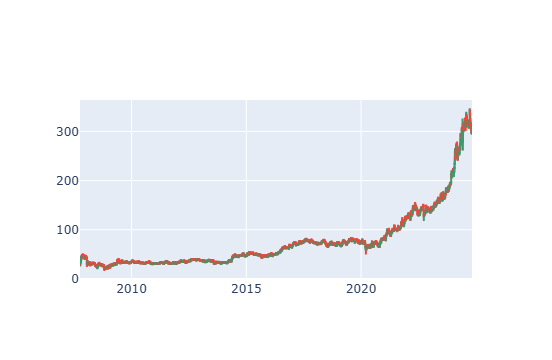

In [14]:
# Candlesticks 
import plotly.graph_objects as go

fig = go.Figure(data=[go.Candlestick(x = data01['Date'], open = data01['Open'], 
                                    high = data01['High'],
                                    low = data01['Low'], 
                                    close = data01['Close'])])
fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()

In [16]:
df = df.drop(['Adj Close'], axis=1, errors='ignore')

In [17]:
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
0,2007-10-05,30.896240,33.629606,25.537001,27.579348,855215656
1,2007-10-08,29.314575,31.940448,29.130303,31.940448,126671715
2,2007-10-09,31.310844,31.587251,27.748257,29.329922,116725709
3,2007-10-10,31.602604,32.247556,31.326197,32.124707,67931378
4,2007-10-11,35.134480,36.854350,31.326198,36.854350,106320954


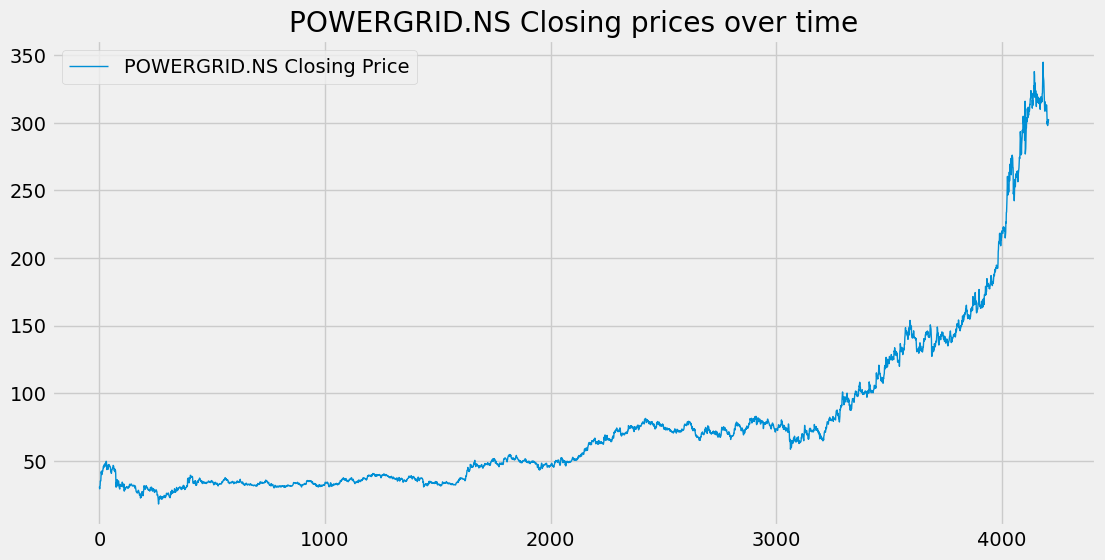

In [18]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label = f'{stock} Closing Price', linewidth = 1)
plt.title(f'{stock} Closing prices over time')
plt.legend()
plt.show()

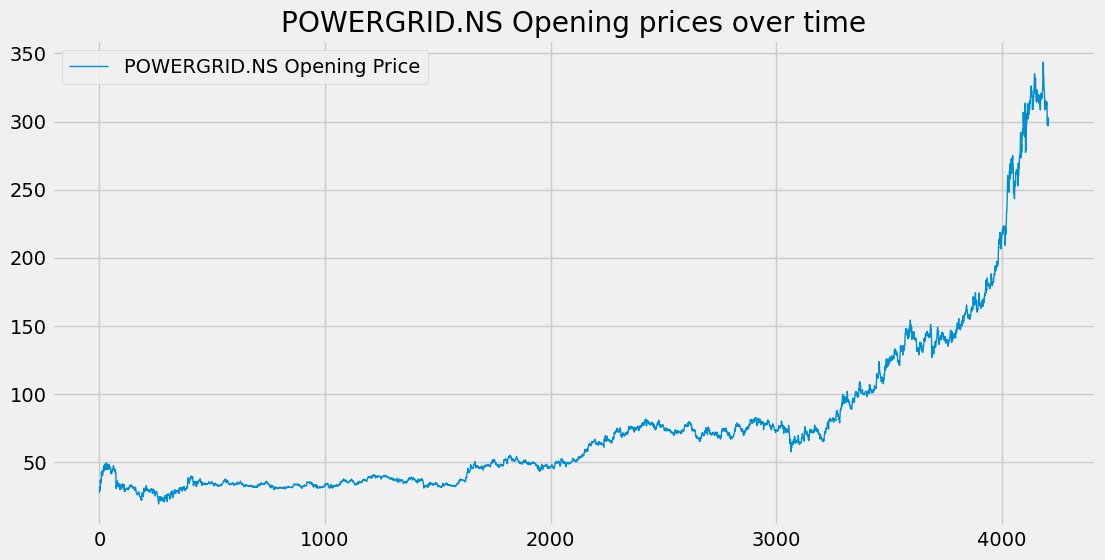

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(df['Open'], label = f'{stock} Opening Price', linewidth = 1)
plt.title(f'{stock} Opening prices over time')
plt.legend()
plt.show()

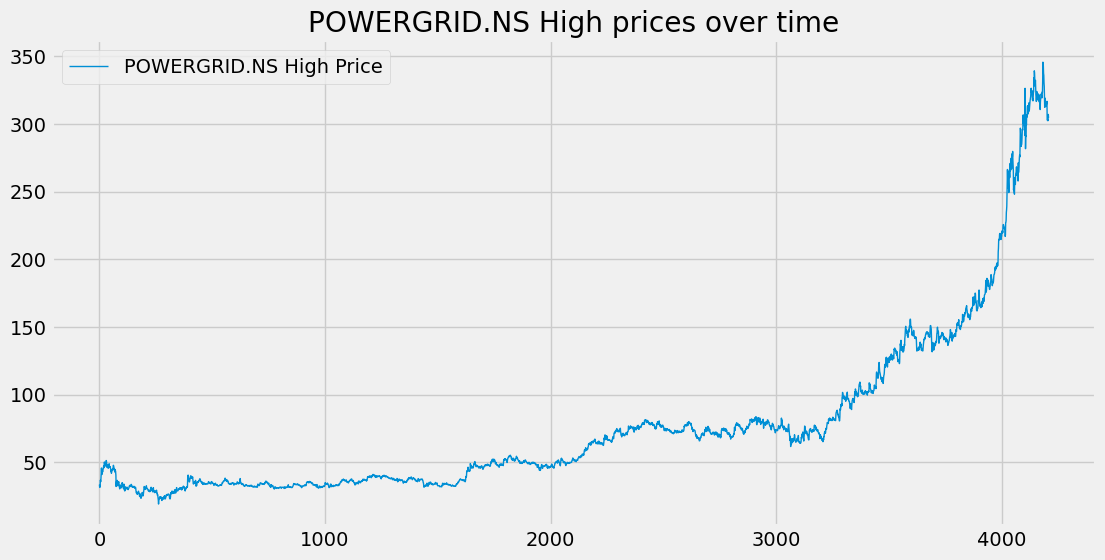

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(df['High'], label = f'{stock} High Price', linewidth = 1)
plt.title(f'{stock} High prices over time')
plt.legend()
plt.show()

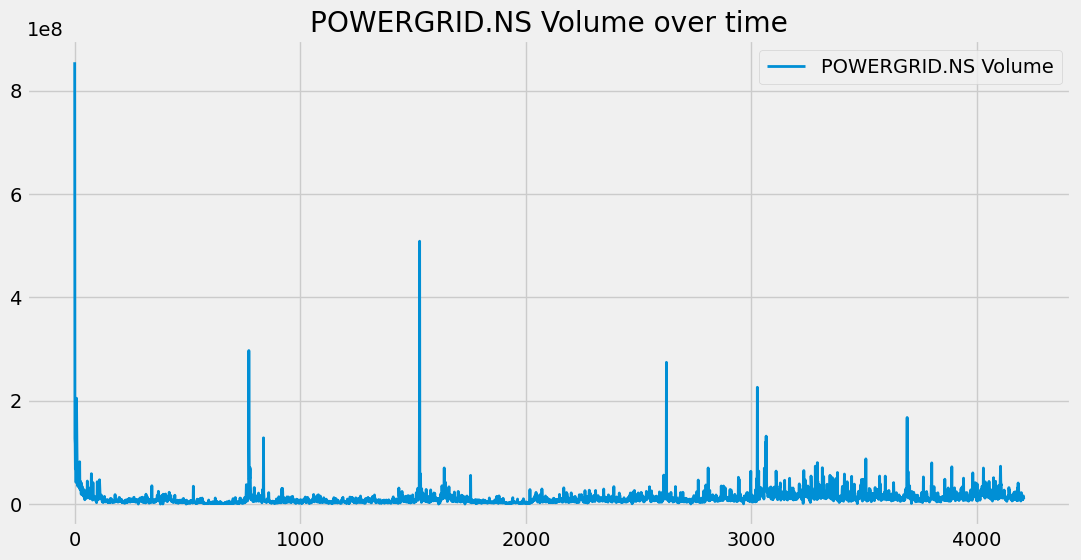

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(df['Volume'], label = f'{stock} Volume', linewidth = 2)
plt.title(f'{stock} Volume over time')
plt.legend()
plt.show()

In [22]:
# Moving Average
# [10, 20, 30, 40, 50, 60, 70, 80, 90]
# moving average for last 5 days -> null null null null 30.0 40.0 50.0

temp_data = [10, 20, 30, 40, 50, 60, 70, 80, 90]
print(sum(temp_data[2:7])/5)

50.0


In [23]:
import pandas as pd
df01 = pd.DataFrame(temp_data)

In [24]:
df01.rolling(5).mean()

,0
0,NaN
1,NaN
2,NaN
3,NaN
4,30.0
5,40.0
6,50.0
7,60.0
8,70.0


In [25]:
ma100 = df.Close.rolling(100).mean()

In [26]:
ma100

Ticker,POWERGRID.NS
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
4203,314.707863
4204,314.941788
4205,315.170273
4206,315.363502


In [27]:
ma200 = df.Close.rolling(200).mean()

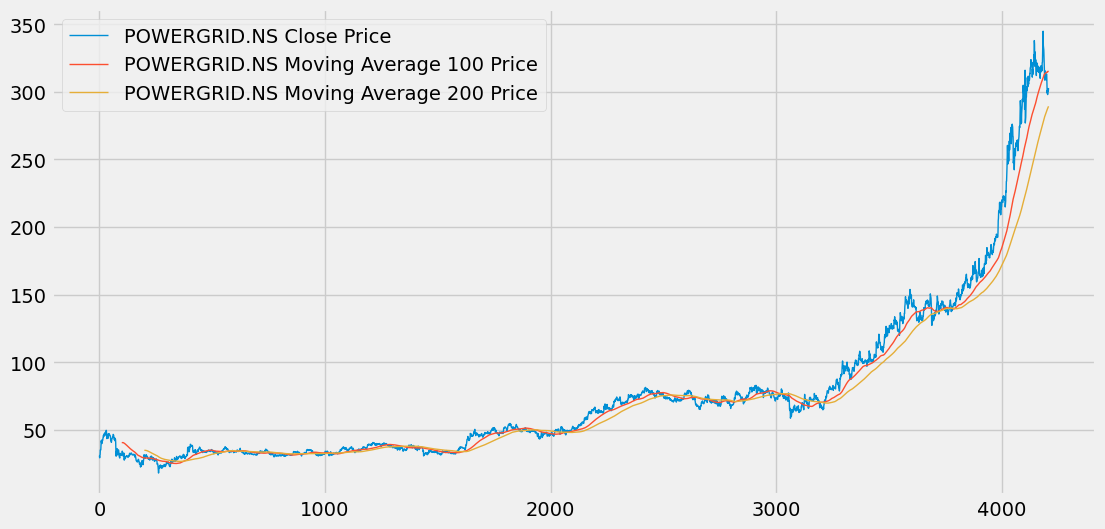

In [28]:
plt.figure(figsize=(12, 6))
plt.plot(df.Close, label = f'{stock} Close Price', linewidth = 1)
plt.plot(ma100, label = f'{stock} Moving Average 100 Price', linewidth = 1)
plt.plot(ma200, label = f'{stock} Moving Average 200 Price', linewidth = 1)
plt.legend()
plt.show()

In [29]:
ema100 = df.Close.ewm(span=100, adjust = False).mean()

In [30]:
ema200 = df['Close'].ewm(span=200, adjust = False).mean()

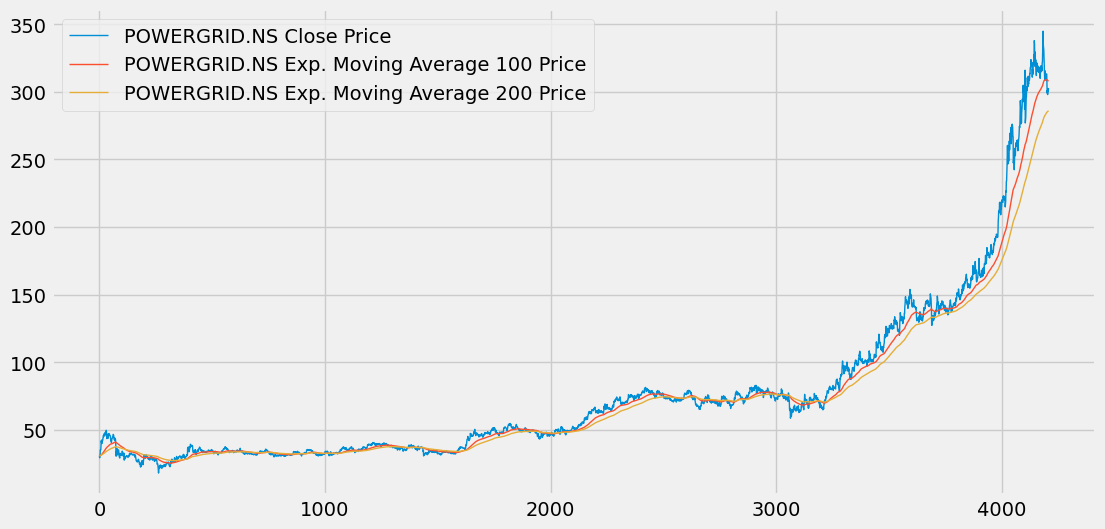

In [31]:
plt.figure(figsize=(12, 6))
plt.plot(df.Close, label = f'{stock} Close Price', linewidth = 1)
plt.plot(ema100, label = f'{stock} Exp. Moving Average 100 Price', linewidth = 1)
plt.plot(ema200, label = f'{stock} Exp. Moving Average 200 Price', linewidth = 1)
plt.legend()
plt.show()

In [32]:
# Training & Testing

data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70): int(len(df))])

In [33]:
data_training.shape

(2945, 1)

In [34]:
data_testing.shape

(1263, 1)

In [35]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range = (0, 1))

In [36]:
data_training_array = scaler.fit_transform(data_training)

In [37]:
data_training_array

array([[0.19808621],
       [0.17371844],
       [0.20447377],
       ...,
       [0.90774435],
       [0.86000391],
       [0.8729966 ]])

In [38]:
data_training_array.shape[0]

2945

In [39]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i, 0])

x_train, y_train  = np.array(x_train), np.array(y_train)

In [40]:
x_train.shape

(2845, 100, 1)

In [41]:
# Model Building
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

I0000 00:00:1786190147.029614     808 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786190147.097910     808 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786190149.741249     808 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [43]:
from keras import Input

model = Sequential()

model.add(Input(shape=(x_train.shape[1], 1)))
model.add(LSTM(units=50, activation='relu', return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=60, activation='relu', return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(units=80, activation='relu', return_sequences=True))
model.add(Dropout(0.4))

model.add(LSTM(units=120, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units=1))

In [44]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error')
model.fit(x_train, y_train, epochs = 50)

Epoch 1/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 20s 171ms/step - loss: 0.0441
Epoch 2/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 15s 170ms/step - loss: 0.0088
Epoch 3/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 18s 198ms/step - loss: 0.0074
Epoch 4/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 15s 169ms/step - loss: 0.0070
Epoch 5/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - loss: 0.0067
Epoch 6/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 15s 171ms/step - loss: 0.0062
Epoch 7/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - loss: 0.0053
Epoch 8/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 17s 185ms/step - loss: 0.0052
Epoch 9/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 15s 172ms/step - loss: 0.0056
Epoch 10/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 15s 168ms/step - loss: 0.0050
Epoch 11/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - loss: 0.0048
Epoch 12/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 178ms/step - loss: 0.0045
Epoch 13/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 15s 168ms/step - loss: 0.0044
Epoch 14/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 15s 168ms/step - loss: 0.0041
Epoch 15/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 17s 

In [46]:
past_100_days = data_training.tail(100)

In [48]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)

In [49]:
final_df.head()

Ticker,POWERGRID.NS
0,72.249100
1,73.721985
2,73.973915
3,73.818893
4,74.245255


In [50]:
input_data = scaler.fit_transform(final_df)

In [51]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i, 0])

x_test, y_test  = np.array(x_test), np.array(y_test)

In [52]:
x_test.shape

(1263, 100, 1)

In [53]:
y_predicted = model.predict(x_test)

40/40 ━━━━━━━━━━━━━━━━━━━━ 40s 949ms/step


In [54]:
y_predicted.shape

(1263, 1)

In [56]:
scaler.scale_

array([0.00349382])

In [57]:
scaler_factor = 1 / 0.0035166
y_predicted = y_predicted * scaler_factor
y_test = y_test * scaler_factor

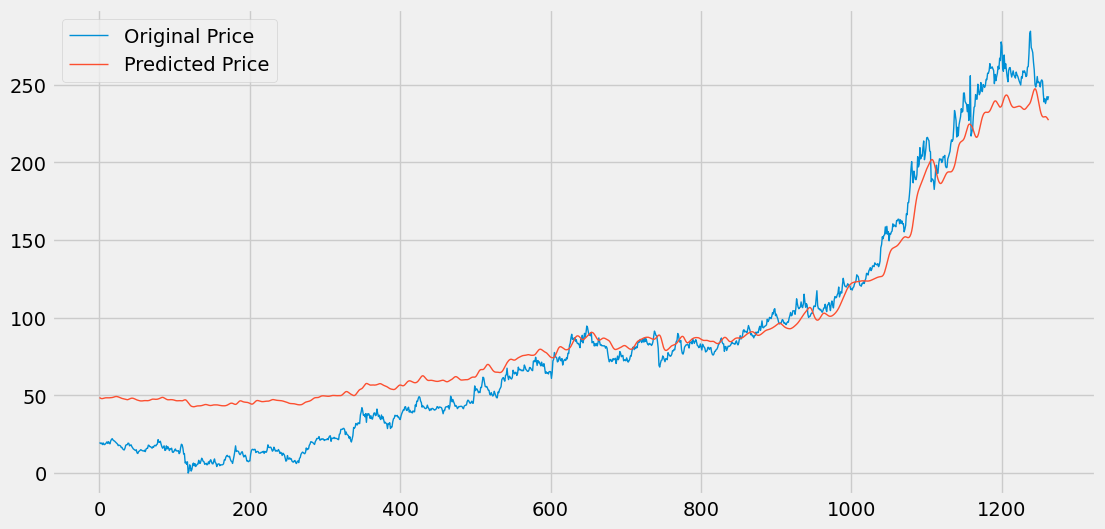

In [58]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, label = 'Original Price', linewidth = 1)
plt.plot(y_predicted, label = 'Predicted Price', linewidth = 1)
plt.legend()
plt.show()

In [59]:
model.save('stock_dl_model.h5')